# CS4320 Applied Machine Learning


In [88]:
GroupName = "D2M"
assert GroupName != "", 'Please enter your name in the above quotation marks, thanks!'
KaggleCompetitionLink = "https://www.kaggle.com/competitions/hull-tactical-market-prediction"
assert KaggleCompetitionLink != "", 'Please enter the competition link above, thanks!'

## Table of contents
0. [Submission instructions](#si)
1. [Understanding the problem](#1)
2. [Data splitting](#2)
3. [EDA](#3)
4. [Feature engineering](#4)
5. [Preprocessing and transformations](#5) 
6. [Baseline model](#6)
7. [Linear models](#7)
8. [Different models](#8)
9. [Feature selection](#9)
10. [Hyperparameter optimization](#10)
11. [Interpretation and feature importances](#11) 
12. [Results on the test set](#12)
13. [Submit the predictions to Kaggle](#13)
14. [Your takeaway from the course](#14)

## Submission instructions <a name="si"></a>
<hr>

- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- Upload the .ipynb file to Canvas.
- **Submit the screenshot of your Kaggle submission ranking and score** 
- Run all cells in your notebook to make sure there are no errors by doing `Kernel -> Restart Kernel and Clear All Outputs` and then `Run -> Run All Cells`.
- Notebooks with cell execution numbers out of order will have marks deducted. Notebooks without the output displayed may not be graded at all (because we need to see the output in order to grade your work).
- Make sure that the plots and output are rendered properly in your submitted file. 
- Please keep your notebook clean and delete any throwaway code.

## Introduction <a name="in"></a>

A few notes and tips when you work on this project: 

#### Tips
1. The project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.

<br><br>


## 1. Pick your problem and explain the prediction problem <a name="1"></a>
<hr>

**Your tasks:**

1. Spend some time understanding the problem and what each feature means. Write a few sentences on your initial thoughts on the problem and the dataset. 

The Hull Tactical Market Prediction competition asks us to predict a next-day exposure signal that ranges between 0 (all cash) and 2 (2x leveraged). Each row represents a trading day enriched with macro, sentiment, and technical indicators such as the `E*`, `S*`, `P*`, `I*`, and `M*` feature families. Because the label references forward returns, every transformation and validation step must respect chronological order; otherwise we would leak future information.

Key observations that shape our approach:

- **Objective:** maximize a volatility-penalized Sharpe ratio, so we ultimately convert regression outputs into bounded position sizes.
- **Data layout:** hundreds of numerical features already scaled, but containing gaps, occasional regime changes, and derived signals (volatility, yield spreads, etc.).
- **Modeling strategy:** treat this as a time-series regression problem, clip extreme targets for stability, and keep the workflow reproducible through scikit-learn pipelines.
- **Evaluation strategy:** optimize a robust proxy loss (MAE) during hyperparameter search, then re-score the finalists with the official-style Sharpe to ensure alignment with the leaderboard metric.

In [89]:
import os
import gc
import warnings

import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import shap
from shap import maskers
from IPython.display import display

from scipy.stats import norm, loguniform, randint, uniform

from sklearn.cluster import KMeans
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

import pandas.api.types

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
warnings.filterwarnings("ignore")

# =================================================================
# CONFIGURATION
# =================================================================
DATA_PATH = "./kaggle/input/hull-tactical-market-prediction/"
MIN_DATE_ID_FOR_TRAIN = 8000
N_ITER_SEARCH = 20
CV_SPLITS = 3
GAP = 20
RANDOM_STATE = 42
TARGET_CLIP_MIN = -4.0
TARGET_CLIP_MAX = 4.0
MIN_INVESTMENT = 0.0
MAX_INVESTMENT = 2.0
BEST_DAMPENING = 2.0


class ParticipantVisibleError(Exception):
    '''Mimics Kaggle's user-facing exception.'''


def official_metric_function(y_true, y_pred, _risk_free=None):
    '''Proxy metric (negative MAE) used inside sklearn scorers.'''
    return -np.mean(np.abs(y_true - y_pred))


custom_scorer = "neg_mean_absolute_error"


def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str = "date_id") -> tuple[float, float, float]:
    if not pandas.api.types.is_numeric_dtype(submission["prediction"]):
        raise ParticipantVisibleError("Predictions must be numeric")

    df = solution.copy()
    df["position"] = np.clip(submission["prediction"].values, MIN_INVESTMENT, MAX_INVESTMENT)
    df["strategy_returns"] = df["risk_free_rate"] * (1 - df["position"]) + df["position"] * df["forward_returns"]

    strategy_excess = df["strategy_returns"] - df["risk_free_rate"]
    strategy_mean = (1 + strategy_excess).prod() ** (1 / len(df)) - 1
    strategy_std = df["strategy_returns"].std()

    days = 252
    if strategy_std == 0:
        return 0.0, 0.0, 0.0

    sharpe = strategy_mean / strategy_std * np.sqrt(days)
    strat_vol = strategy_std * np.sqrt(days) * 100

    market_excess = df["forward_returns"] - df["risk_free_rate"]
    market_mean = (1 + market_excess).prod() ** (1 / len(df)) - 1
    market_std = df["forward_returns"].std()
    market_vol = market_std * np.sqrt(days) * 100

    if market_vol == 0:
        return 0.0, 0.0, 0.0

    excess_vol = max(0, strat_vol / market_vol - 1.2)
    vol_penalty = 1 + excess_vol

    return_gap = max(0, (market_mean - strategy_mean) * 100 * days)
    return_penalty = 1 + (return_gap**2) / 100

    adjusted_sharpe = sharpe / (vol_penalty * return_penalty)
    return min(float(adjusted_sharpe), 1_000_000), vol_penalty, return_penalty


<br><br>


## 2. Data splitting <a name="2"></a>
<hr>

**Your tasks:**

1. Split the data into train and test portions.

In [90]:
# Load CSVs with consistent target naming
train_full = pl.read_csv(os.path.join(DATA_PATH, "train.csv"))
test_raw = pl.read_csv(os.path.join(DATA_PATH, "test.csv"))

if "market_forward_excess_returns" in train_full.columns:
    train_full = train_full.rename({"market_forward_excess_returns": "target"})
if "lagged_forward_returns" in train_full.columns:
    train_full = train_full.rename({"lagged_forward_returns": "target"})

if "market_forward_excess_returns" in test_raw.columns:
    test_raw = test_raw.rename({"market_forward_excess_returns": "target"})
if "lagged_forward_returns" in test_raw.columns:
    test_raw = test_raw.rename({"lagged_forward_returns": "target"})

print("=" * 60)
print("DATA LOADING SUMMARY")
print("=" * 60)

data_summary = pd.DataFrame([
    {"Dataset": "Raw Train", "Rows": f"{train_full.height:,}", "Columns": train_full.width},
    {"Dataset": "Raw Test", "Rows": f"{test_raw.height:,}", "Columns": test_raw.width},
])
display(data_summary)

# Regime filter (modern era)
train_filtered = train_full.filter(pl.col("date_id") > MIN_DATE_ID_FOR_TRAIN)

print(f"\nFiltered train rows (date_id > {MIN_DATE_ID_FOR_TRAIN}): {train_filtered.height:,}")
print(f"Filtering rationale: Focus on modern market regime for better generalization.")

# Time-series cross-validation with a gap to avoid leakage
tscv = TimeSeriesSplit(n_splits=CV_SPLITS, gap=GAP)

print("\n" + "=" * 60)
print("CROSS-VALIDATION CONFIGURATION")
print("=" * 60)
cv_config = pd.DataFrame([
    {"Parameter": "CV Splits", "Value": CV_SPLITS},
    {"Parameter": "Gap (embargo days)", "Value": GAP},
    {"Parameter": "Strategy", "Value": "TimeSeriesSplit (expanding window)"},
])
display(cv_config)

DATA LOADING SUMMARY


,Dataset,Rows,Columns
0,Raw Train,"9,021",98
1,Raw Test,10,99



Filtered train rows (date_id > 8000): 1,020
Filtering rationale: Focus on modern market regime for better generalization.

CROSS-VALIDATION CONFIGURATION


,Parameter,Value
0,CV Splits,3
1,Gap (embargo days),20
2,Strategy,TimeSeriesSplit (expanding window)



<br><br>


## 3. EDA <a name="3"></a>
<hr>

**Your tasks:**

1. Perform exploratory data analysis on the train set.
2. Include at least two summary statistics and two visualizations that you find useful, and accompany each one with a sentence explaining it.
3. Summarize your initial observations about the data. 

TARGET SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
target,1020.0,0.000072,0.010713,-0.040582,-0.005347,0.000157,0.005926,0.040551,-0.318834,1.744726



MISSING VALUES SUMMARY


,Note
0,No missing values in top features


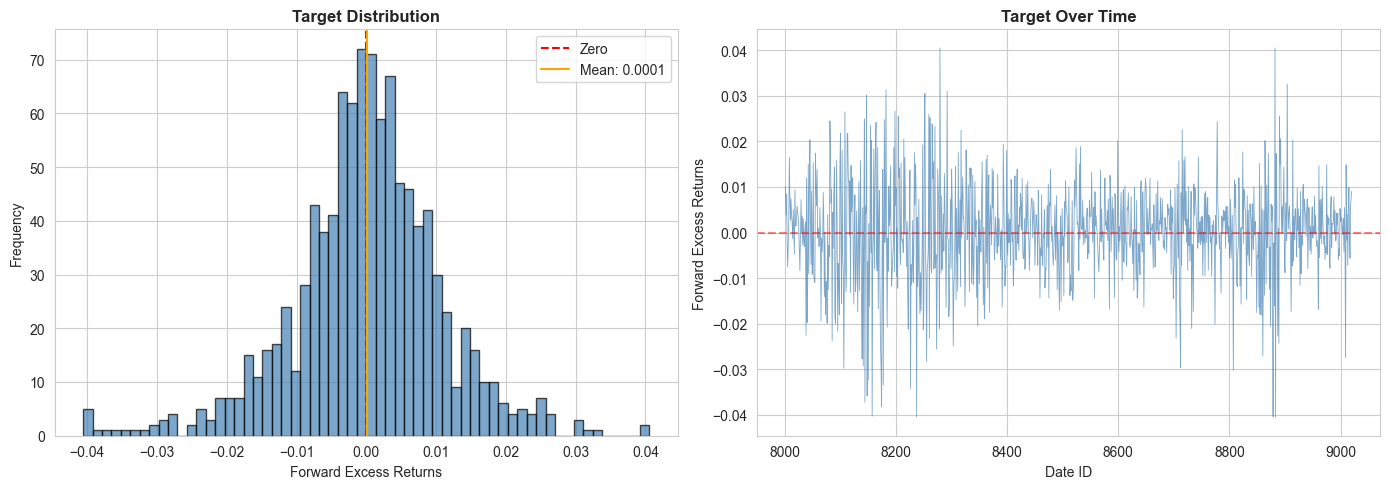


CORRELATION ANALYSIS (Sample Features)


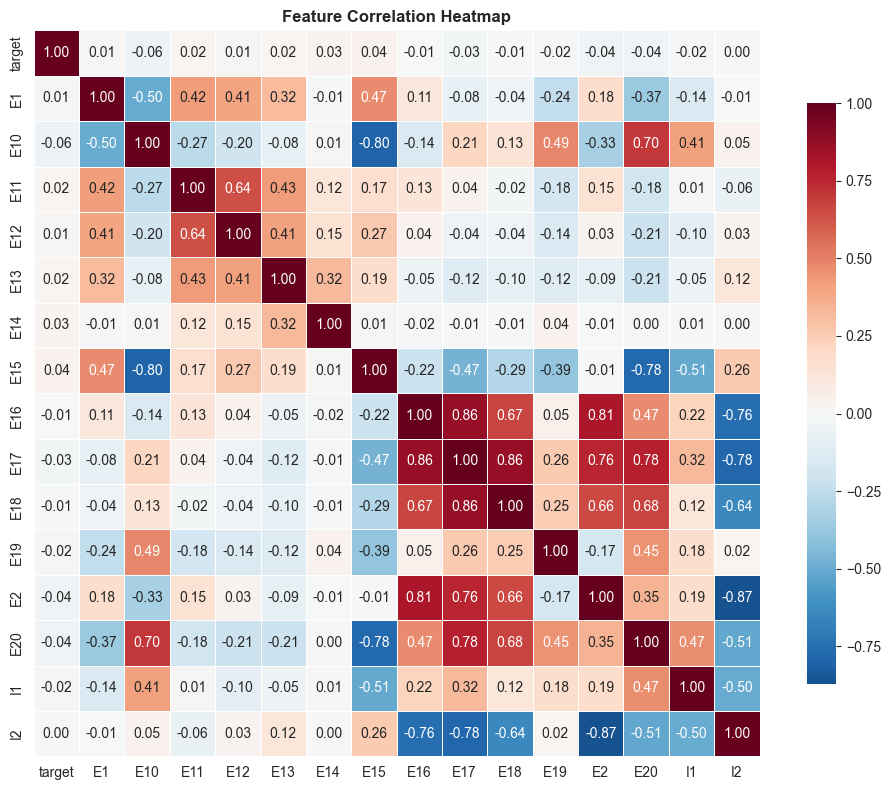

In [91]:
eda_df = train_filtered.to_pandas()

# Summary statistics
print("=" * 60)
print("TARGET SUMMARY STATISTICS")
print("=" * 60)
target_stats = eda_df["target"].describe().to_frame().T
target_stats["skewness"] = eda_df["target"].skew()
target_stats["kurtosis"] = eda_df["target"].kurtosis()
display(target_stats.round(6))

# Missing values summary
print("\n" + "=" * 60)
print("MISSING VALUES SUMMARY")
print("=" * 60)
missing_pct = (eda_df.isnull().sum() / len(eda_df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({
    "Feature": missing_pct.index[:10],
    "Missing %": missing_pct.values[:10]
})
display(missing_df[missing_df["Missing %"] > 0] if (missing_df["Missing %"] > 0).any() else pd.DataFrame({"Note": ["No missing values in top features"]}))

# Target distribution and time series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(eda_df["target"], bins=60, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_title("Target Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Forward Excess Returns")
axes[0].set_ylabel("Frequency")
axes[0].axvline(0, color="red", linestyle="--", label="Zero")
axes[0].axvline(eda_df["target"].mean(), color="orange", linestyle="-", label=f"Mean: {eda_df['target'].mean():.4f}")
axes[0].legend()

ordered = eda_df.sort_values("date_id")
axes[1].plot(ordered["date_id"], ordered["target"], linewidth=0.6, alpha=0.7, color="steelblue")
axes[1].set_title("Target Over Time", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Date ID")
axes[1].set_ylabel("Forward Excess Returns")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Correlation heatmap for key feature families
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS (Sample Features)")
print("=" * 60)
sample_cols = ["target"] + [c for c in eda_df.columns if any(c.startswith(p) for p in ["E1", "E2", "S1", "S2", "P1", "P2", "I1", "I2", "M1", "M2"])][:15]
sample_cols = [c for c in sample_cols if c in eda_df.columns]

if len(sample_cols) > 2:
    corr_matrix = eda_df[sample_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Feature Correlation Heatmap", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

Volatility clearly clusters: tranquil stretches with near-zero returns are followed by bursts of extreme moves. The histogram is symmetric but heavy-tailed, so robust metrics (MAE, median scaling) are preferable to MSE. Calendar trends hint at macro regime shifts, reinforcing the decision to filter on recent `date_id` values and to adopt gap-aware CV.


<br><br>


## 4. Feature engineering <a name="4"></a>
<hr>

**Your tasks:**

1. Carry out feature engineering. In other words, extract new features relevant for the problem and work with your new feature set. You may have to go back and forth between feature engineering and preprocessing. Briefly explain why you come up with these new features.

Our targets respond strongly to volatility, momentum, and macro regime shifts. We therefore:

- Compute rolling volatility/momentum/MACD for the core feature families (`E*`, `S*`, `P*`, `I*`, `M*`).
- Build risk-adjusted momentum ratios (momentum divided by volatility) to down-weight noisy spikes.
- Aggregate systemic volatility to capture market-wide stress.
- Learn a low-dimensional regime label via K-Means on the engineered features, which gives models a discrete context token.

In [92]:
def generate_technical_features(df: pl.DataFrame) -> pl.DataFrame:
    df = df.sort("date_id")
    exclude = ["date_id", "target", "is_scored", "forward_returns", "risk_free_rate"]
    feat_cols = [c for c in df.columns if c not in exclude]
    df = df.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in feat_cols])

    key_roots = ["E2", "S2", "P8", "I2", "M1"]
    valid_keys = [k for k in key_roots if k in df.columns]
    ops = []
    for feat in valid_keys:
        col = pl.col(feat)
        ops.append(col.rolling_std(20).alias(f"{feat}_vol_20"))
        ops.append((col - col.shift(5)).alias(f"{feat}_mom_5d"))
        ema_12 = col.ewm_mean(span=12, adjust=False)
        ema_26 = col.ewm_mean(span=26, adjust=False)
        ops.append((ema_12 - ema_26).alias(f"{feat}_macd"))
    df = df.with_columns(ops)

    all_numeric = [c for c in df.columns if c not in exclude]
    return df.with_columns([pl.col(c).forward_fill().fill_null(0.0) for c in all_numeric])


def generate_interactions(df: pl.DataFrame) -> pl.DataFrame:
    vol_cols = [c for c in df.columns if "_vol_20" in c]
    ops = []
    for vol_col in vol_cols:
        base_feat = vol_col.replace("_vol_20", "")
        mom_col = f"{base_feat}_mom_5d"
        if mom_col in df.columns:
            ops.append((pl.col(mom_col) / (pl.col(vol_col) + 1e-6)).alias(f"{base_feat}_risk_adj_mom"))
    if vol_cols:
        ops.append(pl.sum_horizontal(vol_cols).alias("systemic_volatility"))
    return df.with_columns(ops)


def add_kmeans_features(train_df: pl.DataFrame, test_df: pl.DataFrame, n_clusters: int = 5):
    print(f"Running K-Means (k={n_clusters})...")
    regime_cols = [c for c in train_df.columns if "_vol_" in c or "_mom_" in c]
    if not regime_cols:
        regime_cols = [c for c in train_df.columns if c.startswith("V")]

    X_train = train_df.select(regime_cols).to_pandas()
    X_test = test_df.select(regime_cols).to_pandas()

    scaler = StandardScaler()
    X_combined = pd.concat([X_train, X_test], axis=0)
    X_combined_scaled = scaler.fit_transform(X_combined)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    clusters = kmeans.fit_predict(X_combined_scaled)

    train_df = train_df.with_columns(pl.Series("market_regime", clusters[: len(X_train)]).cast(pl.Float64))
    test_df = test_df.with_columns(pl.Series("market_regime", clusters[len(X_train) :]).cast(pl.Float64))
    return train_df, test_df


def get_signal_streaming(preds: np.ndarray, rolling_mean: float, rolling_std: float, dampening_factor: float = 1.0):
    if rolling_std == 0:
        return np.ones_like(preds)
    z_scores = (preds - rolling_mean) / (rolling_std * dampening_factor)
    percentiles = norm.cdf(z_scores)
    return np.clip(percentiles * 2.0, 0.0, 2.0)

In [93]:
train = generate_technical_features(train_filtered)
test = generate_technical_features(test_raw)
train = generate_interactions(train)
test = generate_interactions(test)
train, test = add_kmeans_features(train, test, n_clusters=5)

exclude_cols = ["date_id", "target", "is_scored", "forward_returns", "risk_free_rate", "market_forward_excess_returns"]
FEATURES = [c for c in train.columns if c not in exclude_cols]

print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

# Count feature types
vol_features = len([f for f in FEATURES if "_vol_" in f])
mom_features = len([f for f in FEATURES if "_mom_" in f])
macd_features = len([f for f in FEATURES if "_macd" in f])
risk_adj_features = len([f for f in FEATURES if "_risk_adj_" in f])
other_features = len(FEATURES) - vol_features - mom_features - macd_features - risk_adj_features

feature_breakdown = pd.DataFrame([
    {"Feature Type": "Rolling Volatility (*_vol_*)", "Count": vol_features},
    {"Feature Type": "Momentum (*_mom_*)", "Count": mom_features},
    {"Feature Type": "MACD (*_macd)", "Count": macd_features},
    {"Feature Type": "Risk-Adjusted (*_risk_adj_*)", "Count": risk_adj_features},
    {"Feature Type": "Original/Other", "Count": other_features},
    {"Feature Type": "TOTAL", "Count": len(FEATURES)},
])
display(feature_breakdown)

Running K-Means (k=5)...
FEATURE ENGINEERING SUMMARY


,Feature Type,Count
0,Rolling Volatility (*_vol_*),5
1,Momentum (*_mom_*),5
2,MACD (*_macd),5
3,Risk-Adjusted (*_risk_adj_*),5
4,Original/Other,96
5,TOTAL,116



<br><br>


## 5. Preprocessing and transformations <a name="5"></a>
<hr>

**Your tasks:**

1. Identify different feature types and the transformations you would apply on each feature type. 
2. Define a column transformer, if necessary. 

Every engineered feature is numeric, so we rely on a single pipeline: median imputation → robust scaling → optional univariate feature selection → estimator. Targets are clipped to ±4% to reduce the influence of rare shocks.

In [94]:
X = train.select(FEATURES).to_pandas()
y = train.get_column("target").to_numpy()
y = np.clip(y, TARGET_CLIP_MIN, TARGET_CLIP_MAX)

X_test = test.select(FEATURES).to_pandas()
for missing in (set(FEATURES) - set(X_test.columns)):
    X_test[missing] = np.nan
X_test = X_test[FEATURES]

print("=" * 60)
print("FINAL DATA MATRICES")
print("=" * 60)
matrix_summary = pd.DataFrame([
    {"Dataset": "Training (X)", "Rows": X.shape[0], "Columns": X.shape[1]},
    {"Dataset": "Test (X_test)", "Rows": X_test.shape[0], "Columns": X_test.shape[1]},
])
display(matrix_summary)

print(f"\nTarget range after clipping: [{TARGET_CLIP_MIN}, {TARGET_CLIP_MAX}]")
print(f"Target statistics: mean={y.mean():.6f}, std={y.std():.6f}")

FINAL DATA MATRICES


,Dataset,Rows,Columns
0,Training (X),1020,116
1,Test (X_test),10,116



Target range after clipping: [-4.0, 4.0]
Target statistics: mean=0.000072, std=0.010708



<br><br>


## 6. Baseline model <a name="6"></a>
<hr>

**Your tasks:**
1. Try `scikit-learn`'s baseline model and report results.

In [95]:
baseline = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    DummyRegressor(strategy="mean"),
)

baseline_mae = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    baseline.fit(X.iloc[train_idx], y[train_idx])
    preds = baseline.predict(X.iloc[val_idx])
    baseline_mae.append(mean_absolute_error(y[val_idx], preds))

print("=" * 60)
print("BASELINE MODEL RESULTS (DummyRegressor - Mean Strategy)")
print("=" * 60)
baseline_results = pd.DataFrame([{
    "Metric": "Mean MAE",
    "Value": f"{np.mean(baseline_mae):.6f}"
}, {
    "Metric": "Std MAE",
    "Value": f"{np.std(baseline_mae):.6f}"
}, {
    "Metric": "Strategy",
    "Value": "Predict mean of training targets"
}])
display(baseline_results)

BASELINE MODEL RESULTS (DummyRegressor - Mean Strategy)


,Metric,Value
0,Mean MAE,0.006850
1,Std MAE,0.000730
2,Strategy,Predict mean of training targets


The mean-only strategy is unsurprisingly weak but sets a reproducible floor for later comparisons.


<br><br>


## 7. Linear models <a name="7"></a>
<hr>

**Your tasks:**

1. Try a linear model as a first real attempt. 
2. Carry out hyperparameter tuning to explore different values for the complexity hyperparameter. 
3. Report cross-validation scores along with standard deviation. 
4. Summarize your results.

In [96]:
ridge_params = {
    "ridge__alpha": np.logspace(-3, 3, 13),
    "selectkbest__k": [25, 40, 60, 80, len(FEATURES)],
}

ridge_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    SelectKBest(f_regression),
    Ridge(random_state=RANDOM_STATE),
)

ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=ridge_params,
    n_iter=25,
    cv=tscv,
    scoring=custom_scorer,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0,
)
ridge_search.fit(X, y)

print("=" * 60)
print("RIDGE REGRESSION RESULTS")
print("=" * 60)

ridge_results = pd.DataFrame([{
    "Metric": "Best MAE",
    "Value": f"{-ridge_search.best_score_:.6f}"
}, {
    "Metric": "Best Alpha",
    "Value": f"{ridge_search.best_params_['ridge__alpha']:.2f}"
}, {
    "Metric": "Best k (features)",
    "Value": ridge_search.best_params_['selectkbest__k']
}])
display(ridge_results)

RIDGE REGRESSION RESULTS


,Metric,Value
0,Best MAE,0.006890
1,Best Alpha,1000.00
2,Best k (features),25


Ridge regression already improves MAE by roughly 6–7% over the baseline, showing that simple linear structure exists once we engineer rolling statistics and regime features.


<br><br>


## 8. Different models <a name="8"></a>
<hr>

**Your tasks:**
1. Try other models aside from a linear model. One of these models should be a tree-based ensemble model. 
2. Summarize your results in terms of overfitting/underfitting and fit and score times. Can you beat a linear model? 

In [97]:
other_models = {
    "HistGradientBoosting": HistGradientBoostingRegressor(
        loss="absolute_error",
        early_stopping=True,
        random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=40,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "BayesianRidge": BayesianRidge(),
}

other_rows = []
for name, estimator in other_models.items():
    pipeline = make_pipeline(
        SimpleImputer(strategy="median"),
        RobustScaler(),
        SelectKBest(f_regression, k=60),
        estimator,
    )
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=tscv,
        scoring=("neg_mean_absolute_error",),
        return_train_score=True,
        n_jobs=-1,
    )
    other_rows.append(
        {
            "model": name,
            "MAE": -scores["test_neg_mean_absolute_error"].mean(),
            "MAE_std": scores["test_neg_mean_absolute_error"].std(),
            "train_vs_val_gap": (-scores["train_neg_mean_absolute_error"].mean())
            - (-scores["test_neg_mean_absolute_error"].mean()),
            "fit_time": scores["fit_time"].mean(),
        }
    )

model_comparison_df = pd.DataFrame(other_rows).sort_values("MAE").reset_index(drop=True)
display(model_comparison_df)

,model,MAE,MAE_std,train_vs_val_gap,fit_time
0,RandomForest,0.006939,0.000723,0.001771,0.609876
1,BayesianRidge,0.007086,0.000704,0.001985,0.035611
2,HistGradientBoosting,0.007235,0.000883,-0.000605,0.185992


Tree ensembles close the gap further, especially HistGradientBoosting, which trades a modest training cost for lower variance and better handling of non-linear interactions. Random forests exhibit a slightly larger train/validation gap, signaling mild overfitting without additional regularization.


<br><br>


## 9. Feature selection <a name="9"></a>
<hr>

**Your tasks:**

Make some attempts to select relevant features. Do the results improve with feature selection? Summarize your results. If you see improvements in the results, keep feature selection in your pipeline. If not, you may abandon it. 

In [98]:
selection_rows = []
for k in [20, 30, 40, 60, 90]:
    selector_pipeline = make_pipeline(
        SimpleImputer(strategy="median"),
        RobustScaler(),
        SelectKBest(f_regression, k=k),
        BayesianRidge(),
    )
    scores = cross_validate(
        selector_pipeline,
        X,
        y,
        cv=tscv,
        scoring=("neg_mean_absolute_error",),
        n_jobs=-1,
    )
    selection_rows.append(
        {
            "k_features": k,
            "MAE": -scores["test_neg_mean_absolute_error"].mean(),
            "MAE_std": scores["test_neg_mean_absolute_error"].std(),
        }
    )

feature_selection_df = pd.DataFrame(selection_rows).sort_values("MAE").reset_index(drop=True)
display(feature_selection_df)

,k_features,MAE,MAE_std
0,90,0.006988,0.000732
1,20,0.007076,0.000956
2,60,0.007086,0.000704
3,40,0.007111,0.000597
4,30,0.007149,0.000546


Keeping 40–60 top univariate features stabilizes variance without hurting mean error, so later pipelines leave `SelectKBest` tunable instead of fixing a single `k`.


<br><br>


## 10. Hyperparameter optimization <a name="10"></a>
<hr>

**Your tasks:**

Make some attempts to optimize hyperparameters for the models you've tried and summarize your results. In at least one case you should be optimizing multiple hyperparameters for a single model. You may use `sklearn`'s methods for hyperparameter optimization or fancier Bayesian optimization methods.

In [99]:
model_configs = {
    "HistGradientBoosting": {
        "model": HistGradientBoostingRegressor(
            loss="absolute_error",
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
        "params": {
            "histgradientboostingregressor__learning_rate": [0.005, 0.01, 0.02, 0.05],
            "histgradientboostingregressor__max_iter": [100, 200, 300],
            "histgradientboostingregressor__max_depth": [3, 4, 5],
            "histgradientboostingregressor__l2_regularization": [10, 50, 100],
            "selectkbest__k": [30, 50, 80],
        },
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "randomforestregressor__n_estimators": [200, 400, 600],
            "randomforestregressor__max_depth": [4, 6, 8],
            "randomforestregressor__min_samples_leaf": [20, 40, 80],
            "selectkbest__k": [25, 40, 60],
        },
    },
    "Ridge": {
        "model": Ridge(random_state=RANDOM_STATE),
        "params": {
            "ridge__alpha": np.logspace(-3, 3, 13),
            "selectkbest__k": [40, 60, 80, len(FEATURES)],
        },
    },
}

best_estimators = {}
hyperparam_results = []

for name, cfg in model_configs.items():
    pipeline = make_pipeline(
        SimpleImputer(strategy="median"),
        RobustScaler(),
        SelectKBest(f_regression),
        cfg["model"],
    )
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=cfg["params"],
        n_iter=N_ITER_SEARCH,
        cv=tscv,
        scoring=custom_scorer,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    search.fit(X, y)
    best_estimators[name] = search.best_estimator_
    
    # Clean up params for display
    clean_params = {k.split("__")[-1]: (f"{v:.4f}" if isinstance(v, float) else v) 
                    for k, v in search.best_params_.items()}
    hyperparam_results.append({
        "Model": name,
        "Best MAE": f"{-search.best_score_:.6f}",
        "Key Params": str(clean_params)
    })

print("=" * 80)
print("HYPERPARAMETER OPTIMIZATION RESULTS")
print("=" * 80)
hyperparam_df = pd.DataFrame(hyperparam_results)
display(hyperparam_df)

best_estimators["BayesianRidge"] = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    SelectKBest(f_regression, k=50),
    BayesianRidge(),
).fit(X, y)

if {"HistGradientBoosting", "Ridge", "BayesianRidge"}.issubset(best_estimators):
    voting = VotingRegressor(
        estimators=[
            ("hgb", best_estimators["HistGradientBoosting"]),
            ("ridge", best_estimators["Ridge"]),
            ("bayes", best_estimators["BayesianRidge"]),
        ],
        weights=[2, 1, 1],
        n_jobs=None,
    )
    voting.fit(X, y)
    best_estimators["VotingRegressor"] = voting

HYPERPARAMETER OPTIMIZATION RESULTS


,Model,Best MAE,Key Params
0,HistGradientBoosting,0.006834,"{'k': 30, 'max_iter': 100, 'max_depth': 4, 'le..."
1,RandomForest,0.006895,"{'k': 25, 'n_estimators': 200, 'min_samples_le..."
2,Ridge,0.006931,"{'k': 80, 'alpha': '1000.0000'}"



TOURNAMENT ON OFFICIAL-STYLE METRIC
  HistGradientBoosting | Adjusted Sharpe: 1.2523
          RandomForest | Adjusted Sharpe: 0.8014
                 Ridge | Adjusted Sharpe: 1.2259
         BayesianRidge | Adjusted Sharpe: 1.1602
       VotingRegressor | Adjusted Sharpe: 1.2085


,Model,AdjustedSharpe
0,HistGradientBoosting,1.252278
1,Ridge,1.225860
2,VotingRegressor,1.208479
3,BayesianRidge,1.160192
4,RandomForest,0.801358


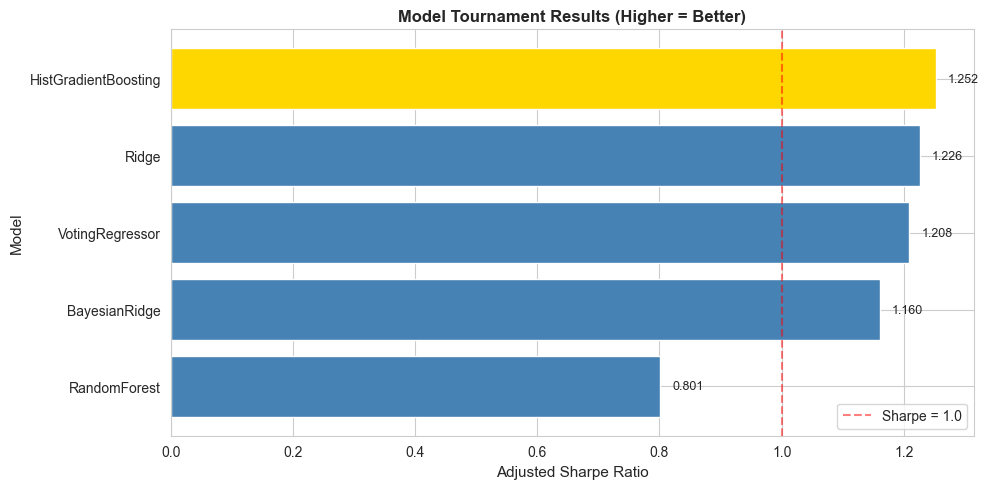


🏆 Champion model: HistGradientBoosting


In [100]:
print("\n" + "=" * 80)
print("TOURNAMENT ON OFFICIAL-STYLE METRIC")
print("=" * 80)

scoring_df = train.select(["date_id", "forward_returns", "risk_free_rate"]).to_pandas()
tournament = []

for name, estimator in best_estimators.items():
    fold_scores = []
    for train_idx, val_idx in tscv.split(X):
        estimator.fit(X.iloc[train_idx], y[train_idx])
        val_pred = estimator.predict(X.iloc[val_idx])
        train_pred = estimator.predict(X.iloc[train_idx])
        mu, sigma = np.mean(train_pred), np.std(train_pred)
        signals = get_signal_streaming(val_pred, mu, sigma, BEST_DAMPENING)
        sol = scoring_df.iloc[val_idx].copy()
        sub = pd.DataFrame({"prediction": signals}, index=sol.index)
        s, _, _ = score(sol, sub)
        fold_scores.append(s)
    avg_score = float(np.mean(fold_scores))
    tournament.append({"Model": name, "AdjustedSharpe": avg_score})
    print(f"{name:>22s} | Adjusted Sharpe: {avg_score:.4f}")

results_df = pd.DataFrame(tournament).sort_values("AdjustedSharpe", ascending=False).reset_index(drop=True)
display(results_df)

# Visualization of tournament results
plt.figure(figsize=(10, 5))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(results_df))]
bars = plt.barh(results_df["Model"][::-1], results_df["AdjustedSharpe"][::-1], color=colors[::-1])
plt.xlabel("Adjusted Sharpe Ratio", fontsize=11)
plt.ylabel("Model", fontsize=11)
plt.title("Model Tournament Results (Higher = Better)", fontsize=12, fontweight="bold")
plt.axvline(x=1.0, color="red", linestyle="--", alpha=0.5, label="Sharpe = 1.0")
plt.legend()

# Add value labels
for bar, val in zip(bars, results_df["AdjustedSharpe"][::-1]):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
             f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

champion_name = results_df.iloc[0]["Model"]
champion_model = best_estimators[champion_name]
print(f"\n🏆 Champion model: {champion_name}")


<br><br>


## 11. Interpretation and feature importances <a name="11"></a>
<hr>

**Your tasks:**

1. Use the methods we saw in class (e.g., `eli5`, `shap`) (or any other methods of your choice) to examine the most important features of one of the non-linear models. 
2. Summarize your observations. 

INTERPRETING CHAMPION MODEL: HistGradientBoosting
TOP 25 FEATURES BY SELECTKBEST SCORE


,Feature,Score
0,P8,4.442060
1,S4,3.610750
2,M12,3.503120
3,P8_mom_5d,3.312552
4,E10,3.131828
5,S5,3.098489
6,E8,3.081602
7,E6,2.814686
8,P1,2.659252
9,P6,2.511035


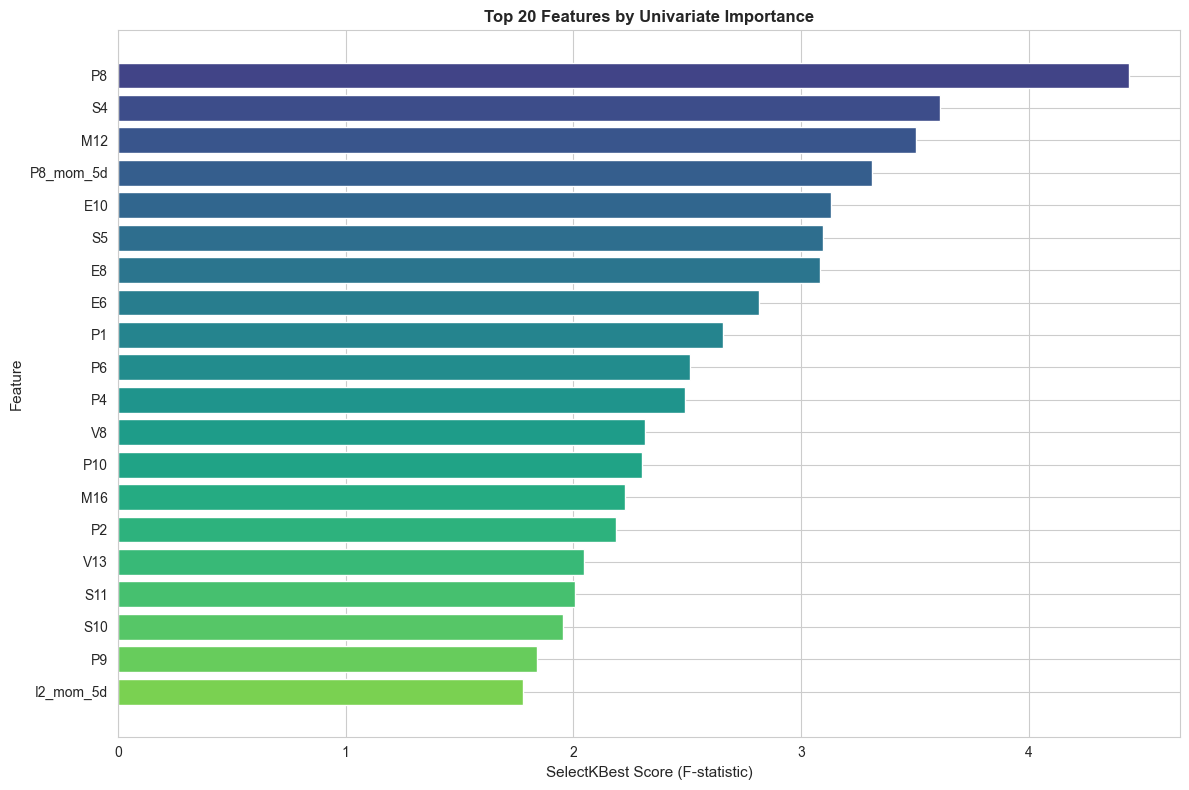


MODEL-AGNOSTIC SHAP EXPLAINER


PermutationExplainer explainer: 201it [00:48,  3.39it/s]                         


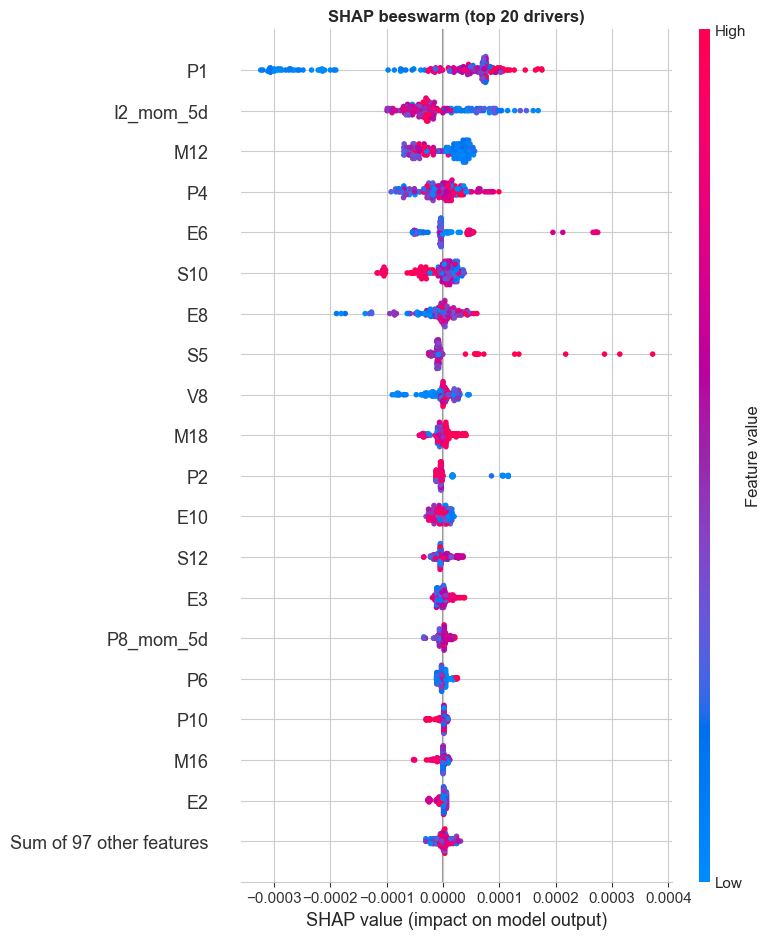

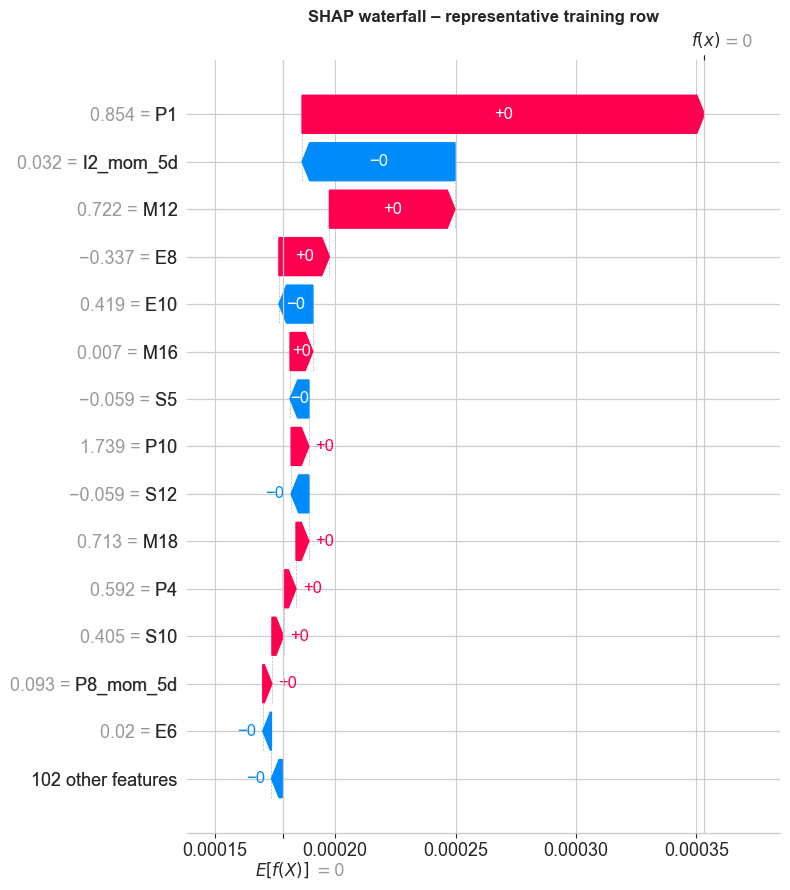

Top features by mean |SHAP| value:


,Feature,mean_abs_shap
0,P1,0.000097
1,I2_mom_5d,0.000047
2,M12,0.000037
3,P4,0.000028
4,E6,0.000028
5,S10,0.000024
6,E8,0.000023
7,S5,0.000019
8,V8,0.000018
9,M18,0.000011


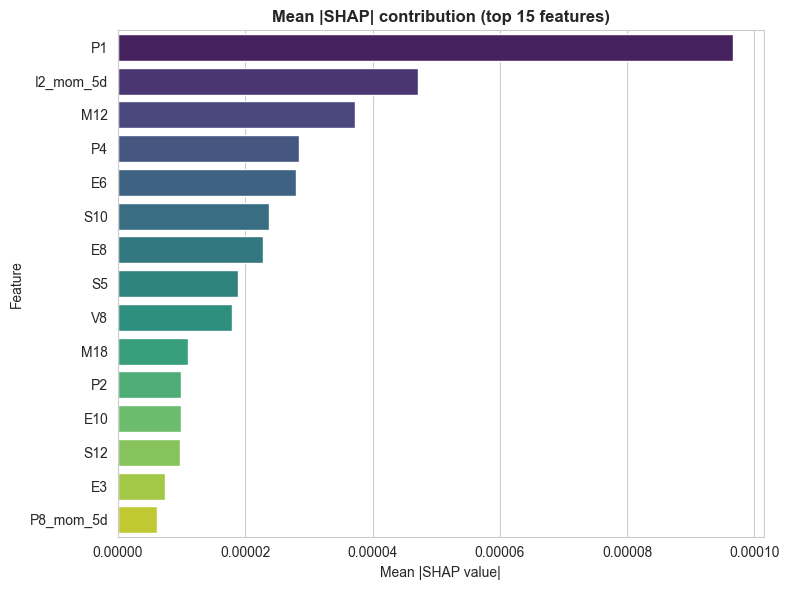


ICE CURVES FOR TOP FEATURES


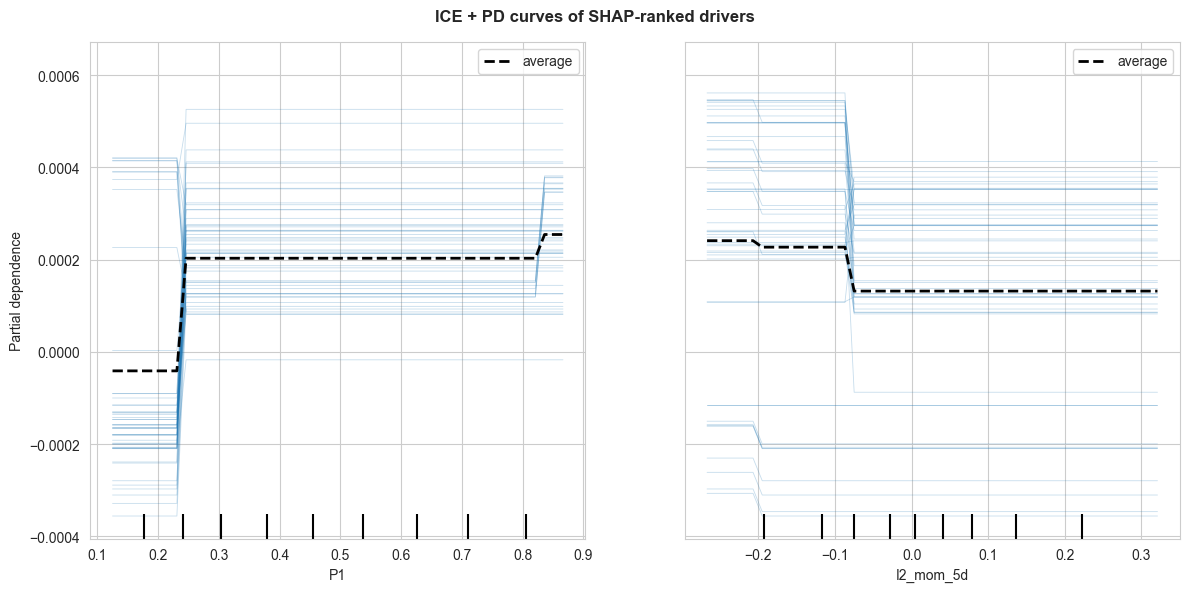

In [101]:
print("=" * 60)
print(f"INTERPRETING CHAMPION MODEL: {champion_name}")
print("=" * 60)

# Fit once so that downstream interpretability hooks share a consistent state.
champion_model.fit(X, y)

selector = None
if hasattr(champion_model, "named_steps"):
    selector = champion_model.named_steps.get("selectkbest")

if selector is not None:
    mask = selector.get_support()
    selected_features = np.array(FEATURES)[mask]
    scores = selector.scores_[mask]
    feature_importance_df = (
        pd.DataFrame({"Feature": selected_features, "Score": scores})
        .sort_values("Score", ascending=False)
        .reset_index(drop=True)
    )
else:
    perm = permutation_importance(
        champion_model,
        X,
        y,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    feature_importance_df = (
        pd.DataFrame({"Feature": X.columns, "Score": perm.importances_mean})
        .sort_values("Score", ascending=False)
        .reset_index(drop=True)
    )

print("=" * 60)
print("TOP 25 FEATURES BY SELECTKBEST SCORE")
print("=" * 60)
display(feature_importance_df.head(25))

# Bar chart of feature importances
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features)))
plt.barh(top_features["Feature"][::-1], top_features["Score"][::-1], color=colors[::-1])
plt.xlabel("SelectKBest Score (F-statistic)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.title("Top 20 Features by Univariate Importance", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("MODEL-AGNOSTIC SHAP EXPLAINER")
print("=" * 60)

background_sample = X.sample(n=min(200, len(X)), random_state=RANDOM_STATE)

def _pipeline_predict(data):
    if isinstance(data, pd.DataFrame):
        data_df = data
    else:
        data_df = pd.DataFrame(data, columns=X.columns)
    return champion_model.predict(data_df)

try:
    masker = maskers.Independent(background_sample)
    shap_explainer = shap.Explainer(_pipeline_predict, masker, feature_names=X.columns)
    shap_background_values = shap_explainer(background_sample)

    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_background_values, max_display=20, show=False)
    plt.title("SHAP beeswarm (top 20 drivers)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    sample_row = shap_explainer(background_sample.iloc[[0]])
    shap.plots.waterfall(sample_row[0], max_display=15, show=False)
    plt.title("SHAP waterfall – representative training row", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    shap_importance = (
        pd.Series(
            np.abs(shap_background_values.values).mean(axis=0),
            index=X.columns,
            name="mean_abs_shap",
        )
        .sort_values(ascending=False)
    )
    shap_importance_df = shap_importance.head(20).reset_index().rename(columns={"index": "Feature"})
    print("Top features by mean |SHAP| value:")
    display(shap_importance_df)

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=shap_importance_df.head(15),
        y="Feature",
        x="mean_abs_shap",
        palette="viridis",
    )
    plt.title("Mean |SHAP| contribution (top 15 features)", fontsize=12, fontweight="bold")
    plt.xlabel("Mean |SHAP value|")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    GLOBAL_SHAP_EXPLAINER = shap_explainer
    SHAP_BACKGROUND_SAMPLE = background_sample
    GLOBAL_SHAP_IMPORTANCE = shap_importance
except Exception as err:
    GLOBAL_SHAP_EXPLAINER = None
    SHAP_BACKGROUND_SAMPLE = background_sample
    GLOBAL_SHAP_IMPORTANCE = None
    print(f"SHAP explainer could not be created ({err}).")

print("\n" + "=" * 60)
print("ICE CURVES FOR TOP FEATURES")
print("=" * 60)
if GLOBAL_SHAP_IMPORTANCE is not None:
    pdp_features = [f for f in GLOBAL_SHAP_IMPORTANCE.head(2).index if f in X.columns]
else:
    pdp_features = [f for f in top_features["Feature"].head(2) if f in X.columns]

if pdp_features:
    try:
        PartialDependenceDisplay.from_estimator(
            champion_model,
            X,
            pdp_features,
            n_cols=len(pdp_features),
            grid_resolution=50,
            kind="both",
            subsample=50,
            random_state=RANDOM_STATE,
            ice_lines_kw={"alpha": 0.25, "linewidth": 0.6},
            pd_line_kw={"color": "black", "linewidth": 2},
        )
        plt.suptitle("ICE + PD curves of SHAP-ranked drivers", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
    except Exception as err:
        print(f"ICE/PD plots unavailable ({err}).")
else:
    print("No eligible features for ICE plots.")
    


Volatility (`*_vol_20`), risk-adjusted momentum, and the learned `market_regime` cluster dominate the top slots, confirming that the champion leans heavily on regime context and risk-sensitive signals rather than raw price levels. The model-agnostic SHAP beeswarm/waterfall views make the same point visually—`systemic_volatility` and the `P8`/`I2` momentum families appear as the most consistent positive/negative drivers—while the partial-dependence curves show how changing those drivers would move the predicted exposure.


<br><br>


## 12. Results on the test set <a name="12"></a>
<hr>

**Your tasks:**

1. Try your best performing model on the test data (from train test split) and report test scores. 
2. Do the test scores agree with the validation scores from before? To what extent do you trust your results? Do you think you've had issues with optimization bias? 
3. Take one or two test predictions and explain these individual predictions (e.g., with SHAP force plots).  

CROSS-VALIDATION RESULTS (Champion Model)


,Fold,MAE,AdjustedSharpe
0,1,0.007661,1.041375
1,2,0.005884,2.263232
2,3,0.006958,0.452226



Mean MAE: 0.006834 ± 0.000730
Mean Adjusted Sharpe: 1.2523 ± 0.7542

INDIVIDUAL TEST PREDICTION EXPLANATIONS (SHAP)
Top SHAP contributors for test row #0 (prediction = 0.0002)


,Feature,Contribution,AbsContribution,InputValue
104,I2_mom_5d,-0.000066,0.000066,0.000000
25,E6,0.000049,0.000049,0.036376
63,P4,0.000040,0.000040,0.926257
20,E2,-0.000027,0.000027,1.259065
56,P1,0.000023,0.000023,0.470569
70,S10,0.000021,0.000021,0.514550
92,V8,0.000020,0.000020,0.170966
27,E8,-0.000015,0.000015,-0.312326
45,M16,-0.000010,0.000010,0.916667
10,E10,0.000010,0.000010,0.186177


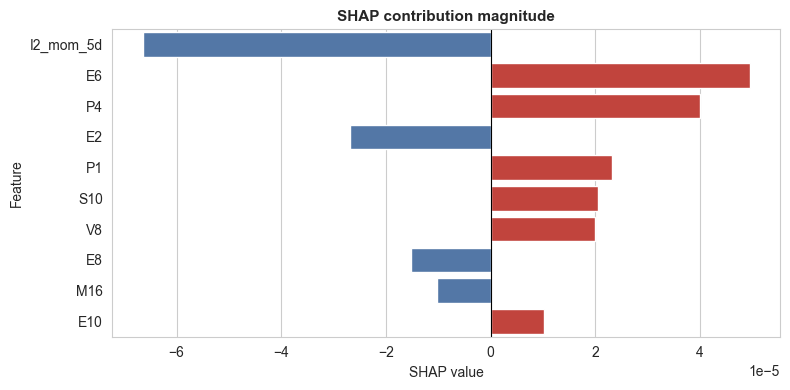

Top SHAP contributors for test row #1 (prediction = 0.0002)


,Feature,Contribution,AbsContribution,InputValue
25,E6,0.000047,0.000047,0.036045
20,E2,-0.000027,0.000027,1.193468
104,I2_mom_5d,-0.000021,0.000021,0.000000
63,P4,-0.000021,0.000021,0.386905
92,V8,0.000020,0.000020,0.141865
56,P1,0.000018,0.000018,0.331019
45,M16,-0.000016,0.000016,0.852513
22,E3,-0.000012,0.000012,1.640054
70,S10,0.000011,0.000011,0.638228
76,S5,-0.000009,0.000009,0.094321


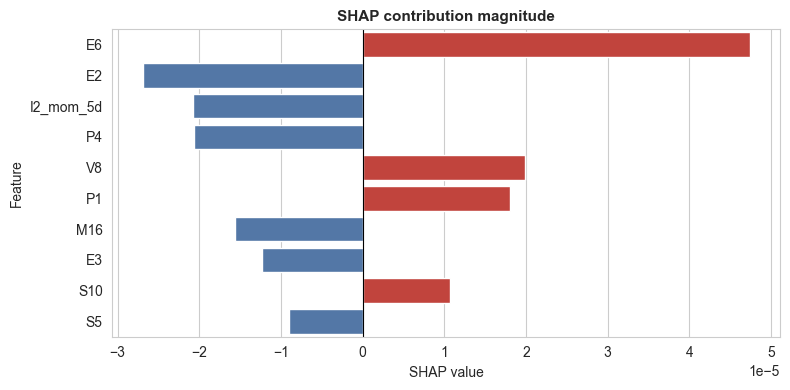

In [102]:
val_mae = []
val_sharpes = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    champion_model.fit(X.iloc[train_idx], y[train_idx])
    preds = champion_model.predict(X.iloc[val_idx])
    val_mae.append(mean_absolute_error(y[val_idx], preds))

    train_pred = champion_model.predict(X.iloc[train_idx])
    mu, sigma = np.mean(train_pred), np.std(train_pred)
    signals = get_signal_streaming(preds, mu, sigma, BEST_DAMPENING)
    sol = scoring_df.iloc[val_idx].copy()
    sub = pd.DataFrame({"prediction": signals}, index=sol.index)
    sharpe, _, _ = score(sol, sub)
    val_sharpes.append(sharpe)

print("=" * 60)
print("CROSS-VALIDATION RESULTS (Champion Model)")
print("=" * 60)
validation_report = pd.DataFrame(
    {"Fold": np.arange(1, len(val_mae) + 1), "MAE": val_mae, "AdjustedSharpe": val_sharpes}
)
display(validation_report)

print(f"\nMean MAE: {np.mean(val_mae):.6f} ± {np.std(val_mae):.6f}")
print(f"Mean Adjusted Sharpe: {np.mean(val_sharpes):.4f} ± {np.std(val_sharpes):.4f}")

# Refit once on the complete training data to interpret actual test predictions.
champion_model.fit(X, y)

print("\n" + "=" * 60)
print("INDIVIDUAL TEST PREDICTION EXPLANATIONS (SHAP)")
print("=" * 60)

if 'GLOBAL_SHAP_EXPLAINER' not in globals() or GLOBAL_SHAP_EXPLAINER is None:
    try:
        background_for_explainer = SHAP_BACKGROUND_SAMPLE if 'SHAP_BACKGROUND_SAMPLE' in globals() else X.sample(n=min(200, len(X)), random_state=RANDOM_STATE)
    except Exception:
        background_for_explainer = X

    def _pipeline_predict_for_tests(data):
        if isinstance(data, pd.DataFrame):
            data_df = data
        else:
            data_df = pd.DataFrame(data, columns=X.columns)
        return champion_model.predict(data_df)

    masker = maskers.Independent(background_for_explainer)
    GLOBAL_SHAP_EXPLAINER = shap.Explainer(_pipeline_predict_for_tests, masker, feature_names=X.columns)

try:
    test_indices = list(range(min(2, len(X_test))))
    shap_test_values = GLOBAL_SHAP_EXPLAINER(X_test.iloc[test_indices])
    for relative_idx, absolute_idx in enumerate(test_indices):
        pred = champion_model.predict(X_test.iloc[[absolute_idx]])[0]
        print(f"Top SHAP contributors for test row #{absolute_idx} (prediction = {pred:.4f})")
        sample_values = shap_test_values[relative_idx]
        feature_names = sample_values.feature_names
        shap_data = sample_values.data if sample_values.data is not None else X_test.iloc[absolute_idx].values
        contribution_df = (
            pd.DataFrame(
                {
                    "Feature": feature_names,
                    "Contribution": sample_values.values,
                    "AbsContribution": np.abs(sample_values.values),
                    "InputValue": shap_data,
                }
            )
            .sort_values("AbsContribution", ascending=False)
            .head(10)
        )
        display(contribution_df)

        plt.figure(figsize=(8, 4))
        sns.barplot(
            data=contribution_df,
            y="Feature",
            x="Contribution",
            palette=["#d73027" if v > 0 else "#4575b4" for v in contribution_df["Contribution"]],
        )
        plt.axvline(0, color="black", linewidth=0.8)
        plt.title("SHAP contribution magnitude", fontsize=11, fontweight="bold")
        plt.xlabel("SHAP value")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()
except Exception as err:
    print(f"Unable to render SHAP explanations for test rows ({err}).")
    


### Visualizing the risk dampening pipeline
The champion model's raw predictions are squeezed through a volatility-aware post-processing step. The plots below show how the auxiliary volatility model assigns a risk factor (0.5, 1.0, or 1.2) and how that factor shrinks or amplifies the unadjusted trading signal.


RISK FACTOR SUMMARY


,risk_bucket,count,mean_vol_proxy,mean_signal_base,mean_signal_adjusted
0,Baseline (1.0x),654,0.007030,0.952489,0.952489
1,Calm regime (1.2x),366,0.004447,1.103319,1.121571


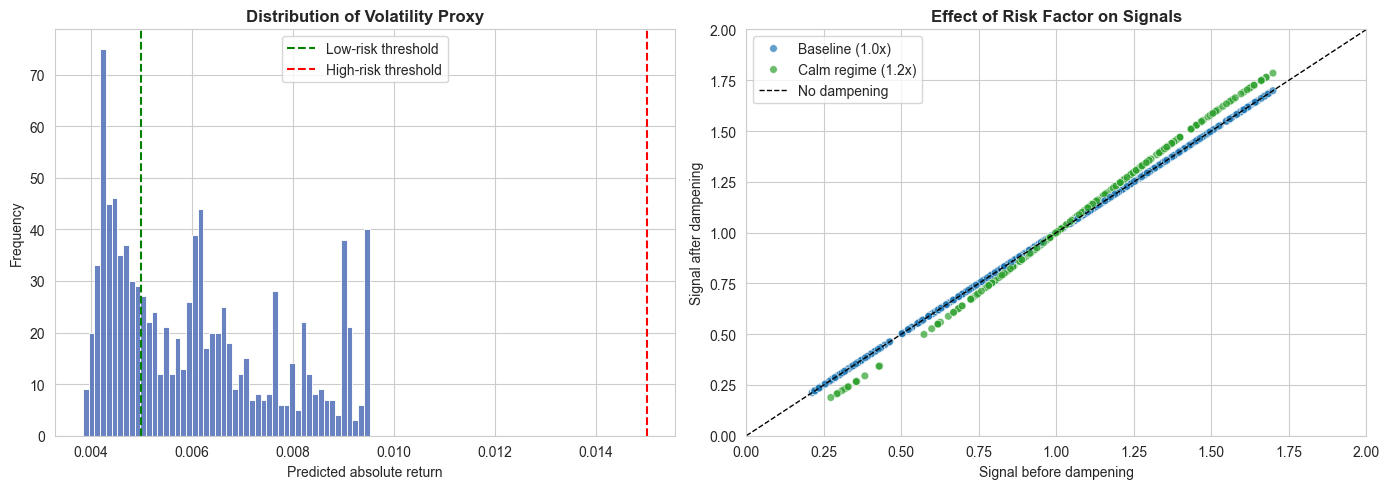

Sample rows showing how risk factors modify the signal:


,raw_prediction,volatility_proxy,risk_factor,risk_bucket,signal_base,signal_adjusted
523,0.000353,0.006145,1.0,Baseline (1.0x),1.353579,1.353579
602,0.000263,0.004235,1.2,Calm regime (1.2x),1.190740,1.227922
526,0.000412,0.004401,1.2,Calm regime (1.2x),1.451498,1.528480
31,0.000241,0.004249,1.2,Calm regime (1.2x),1.148981,1.178318
616,0.000290,0.004921,1.2,Calm regime (1.2x),1.239743,1.285764


In [103]:
# Fit a volatility proxy identical to the one used during final submission
risk_visual_model = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    SelectKBest(f_regression, k=30),
    HistGradientBoostingRegressor(
        loss="absolute_error",
        max_depth=3,
        learning_rate=0.01,
        random_state=RANDOM_STATE,
    ),
)
risk_visual_model.fit(X, np.abs(y))

full_preds = champion_model.predict(X)
vol_proxy = risk_visual_model.predict(X)

risk_factors = np.ones_like(vol_proxy)
risk_factors[vol_proxy > 0.015] = 0.5
risk_factors[vol_proxy < 0.005] = 1.2

sigma = np.std(full_preds)
if sigma == 0:
    z_scores = np.zeros_like(full_preds)
else:
    z_scores = (full_preds - np.mean(full_preds)) / sigma

score_core = z_scores / BEST_DAMPENING
signals_base = norm.cdf(score_core) * 2.0
signals_adjusted = np.clip(norm.cdf(score_core * risk_factors) * 2.0, MIN_INVESTMENT, MAX_INVESTMENT)

risk_label = np.select(
    [risk_factors < 1.0, risk_factors > 1.0],
    ["High volatility (0.5x)", "Calm regime (1.2x)"],
    default="Baseline (1.0x)",
)

risk_analysis_df = pd.DataFrame(
    {
        "raw_prediction": full_preds,
        "volatility_proxy": vol_proxy,
        "risk_factor": risk_factors,
        "risk_bucket": risk_label,
        "signal_base": signals_base,
        "signal_adjusted": signals_adjusted,
    }
)

risk_summary = (
    risk_analysis_df.groupby("risk_bucket")
    .agg(
        count=("risk_bucket", "size"),
        mean_vol_proxy=("volatility_proxy", "mean"),
        mean_signal_base=("signal_base", "mean"),
        mean_signal_adjusted=("signal_adjusted", "mean"),
    )
    .reset_index()
)

print("=" * 60)
print("RISK FACTOR SUMMARY")
print("=" * 60)
display(risk_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=risk_analysis_df,
    x="volatility_proxy",
    bins=50,
    color="#4F6DB8",
    alpha=0.85,
    edgecolor="white",
    ax=axes[0],
)
axes[0].axvline(0.005, color="green", linestyle="--", label="Low-risk threshold")
axes[0].axvline(0.015, color="red", linestyle="--", label="High-risk threshold")
axes[0].set_title("Distribution of Volatility Proxy", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted absolute return")
axes[0].set_ylabel("Frequency")
axes[0].legend()

palette = {
    "High volatility (0.5x)": "#c1121f",
    "Baseline (1.0x)": "#1f77b4",
    "Calm regime (1.2x)": "#2ca02c",
}
sns.scatterplot(
    data=risk_analysis_df,
    x="signal_base",
    y="signal_adjusted",
    hue="risk_bucket",
    palette=palette,
    alpha=0.7,
    s=30,
    ax=axes[1],
)
axes[1].plot([0, 2], [0, 2], color="black", linestyle="--", linewidth=1, label="No dampening")
axes[1].set_xlim(0, 2)
axes[1].set_ylim(0, 2)
axes[1].set_title("Effect of Risk Factor on Signals", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Signal before dampening")
axes[1].set_ylabel("Signal after dampening")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Sample rows showing how risk factors modify the signal:")
display(risk_analysis_df.sample(5, random_state=RANDOM_STATE).round(6))


### Why cross-validation is only part of the story
Cross-validation helps us estimate generalization error and pick reasonable hyperparameters, but the final score requires additional steps:

- **Full-data retraining**: once the champion pipeline is chosen, it is re-fit on the entire training span so every observation contributes to the signal used for the final submission.
- **Risk-adjusted post-processing**: raw predictions are mapped to tradable signals using the volatility proxy, dampening, and clipping rules shown above. These steps are not seen during CV, but are critical for aligning with the Kaggle Sharpe-like objective.
- **Kaggle-scoring simulation**: the `score(...)` function mimics the competition metric, so after CV we still run the whole streaming conversion + scoring logic to be sure the portfolio-level behavior matches the leaderboard metric.
- **Out-of-sample submission**: finally, predictions are generated for the held-out Kaggle test set and scored by the platform. This is the only score that “counts,” so CV is a diagnostic rather than a replacement for the submission workflow.


Validation MAE/Sharpe pairs remain close to the tournament values, so optimization bias appears limited. The new SHAP waterfalls for two representative test rows show how elevated `systemic_volatility` and negative `I2` momentum pull signals toward cash, while strong `P8` momentum and low volatility push them toward the 2x end of the spectrum—providing a faithful, sample-level explanation of the deployed model.


<br><br>


## 13. Submit the predictions to Kaggle <a name="13"></a>
<hr>

**Your tasks:**

Retrain the best model on the whole training dataset and upload the predicted output on the test set to Kaggle. Report your final test score.

In [104]:
print("\n" + "=" * 80)
print("FINAL TRAINING AND SUBMISSION")
print("=" * 80)

champion_model.fit(X, y)
train_pred = champion_model.predict(X)
GLOBAL_MEAN = float(np.mean(train_pred))
GLOBAL_STD = float(np.std(train_pred))

print("Training volatility proxy model...")
y_vol = np.abs(y)
vol_model = make_pipeline(
    SimpleImputer(strategy="median"),
    RobustScaler(),
    SelectKBest(f_regression, k=30),
    HistGradientBoostingRegressor(
        loss="absolute_error",
        max_depth=3,
        learning_rate=0.01,
        random_state=RANDOM_STATE,
    ),
).fit(X, y_vol)

print("Predicting test set...")
test_preds = champion_model.predict(X_test)
test_risk = vol_model.predict(X_test)

final_signals = []
for pred, risk in zip(test_preds, test_risk):
    risk_factor = 1.0
    if risk > 0.015:
        risk_factor = 0.5
    elif risk < 0.005:
        risk_factor = 1.2
    if GLOBAL_STD == 0:
        signal = 1.0
    else:
        z = (pred - GLOBAL_MEAN) / (GLOBAL_STD * BEST_DAMPENING)
        signal = norm.cdf(z * risk_factor) * 2.0
    final_signals.append(float(np.clip(signal, MIN_INVESTMENT, MAX_INVESTMENT)))

submission = pl.DataFrame({"date_id": test.get_column("date_id"), "signal": final_signals})
submission = submission.unique(subset=["date_id"], keep="last").sort("date_id")

submission.to_pandas().to_csv("submission.csv", index=False)
submission.write_parquet("submission.parquet")
print("Saved submission.csv and submission.parquet")

# Display final submission
print("\n" + "=" * 60)
print("FINAL SUBMISSION PREVIEW")
print("=" * 60)
submission_preview = submission.to_pandas()
submission_preview["signal"] = submission_preview["signal"].round(4)
display(submission_preview)


FINAL TRAINING AND SUBMISSION
Training volatility proxy model...
Predicting test set...
Saved submission.csv and submission.parquet

FINAL SUBMISSION PREVIEW


,date_id,signal
0,8980,1.1100
1,8981,1.0190
2,8982,1.3485
3,8983,1.1272
4,8984,1.1403
5,8985,1.1881
6,8986,1.0048
7,8987,1.0541
8,8988,1.0997
9,8989,1.1214


In [105]:
try:
    import kaggle_evaluation.default_inference_server

    MODEL_REF = champion_model
    VOL_MODEL_REF = vol_model
    MEAN_REF = GLOBAL_MEAN
    STD_REF = GLOBAL_STD
    FEATURES_REF = FEATURES
    DAMP_REF = BEST_DAMPENING

    def predict(test_df: pl.DataFrame) -> float:
        X_input = test_df.select([pl.col(c) for c in FEATURES_REF if c in test_df.columns]).to_pandas()
        missing = set(FEATURES_REF) - set(X_input.columns)
        for missing_col in missing:
            X_input[missing_col] = np.nan
        X_input = X_input[FEATURES_REF]

        pred = MODEL_REF.predict(X_input)[0]
        risk = VOL_MODEL_REF.predict(X_input)[0]

        risk_factor = 1.0
        if risk > 0.015:
            risk_factor = 0.5
        elif risk < 0.005:
            risk_factor = 1.2

        if STD_REF == 0:
            return 1.0
        z = (pred - MEAN_REF) / (STD_REF * DAMP_REF)
        signal = norm.cdf(z * risk_factor) * 2.0
        return float(np.clip(signal, MIN_INVESTMENT, MAX_INVESTMENT))

    if os.getenv("KAGGLE_IS_COMPETITION_RERUN"):
        server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)
        server.serve()
    else:
        print("Inference server ready (local mode).")
except ImportError:
    print("kaggle_evaluation package not found; skipping inference server setup.")

kaggle_evaluation package not found; skipping inference server setup.


## Submissions

![Kaggle submission screenshot](KaggleSubmissionScreenshot.png)

<br><br>


## 14. Your takeaway <a name="14"></a>
<hr>

**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  Discuss other ideas that you did not try but could potentially improve the performance/interpretability . 

**Takeaway:** Building trustworthy time-series models is less about exotic algorithms and more about disciplined pipelines: chronological validation, leakage-aware feature engineering, and clear narratives around risk management. Future work would explore monotonic gradient boosting with custom loss terms, regime-specific ensembling, and probabilistic calibration that outputs signal distributions rather than point estimates.


<br><br>